---

# Programming Multi Layer Perceptrons (MLPs)

---



---

## Setup

---

Imports. `autoreload` ensures that changes in your `.py` files are picked up automatically. You still need to save them before executing a cell again.

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from mlp_layers import relu_forward, relu_backward, tanh_forward, tanh_backward
from mlp_layers import linear_forward, linear_backward
from mlp_layers import softmax, cross_entropy_loss
from model import init_model, forward_pass, backward_pass
from train import load_mnist, compute_accuracy, create_batches, sgd_step, train
import tests

---

## Data Loading

---

MNIST contains 70,000 grayscale images of handwritten digits (0-9), each with size `28 x 28`.

We load and split the data into three parts:
- **Train** (50,000 images): used to train the neural network.
- **Validation** (10,000 images): used during development to monitor generalization.
- **Test** (10,000 images): used only at the end for the final evaluation.

Each image is **flattened** from a `28 x 28` grid into a vector of length (28*28)=`784`, and pixel values are scaled to `[0, 1]` by dividing by `255`.

Training Images : X=torch.Size([50000, 784]), Training Labels : y=torch.Size([50000])
Validation Images : X=torch.Size([10000, 784]), Validation Labels : y=torch.Size([10000])
Test Images : X=torch.Size([10000, 784]), Test Labels : y=torch.Size([10000])


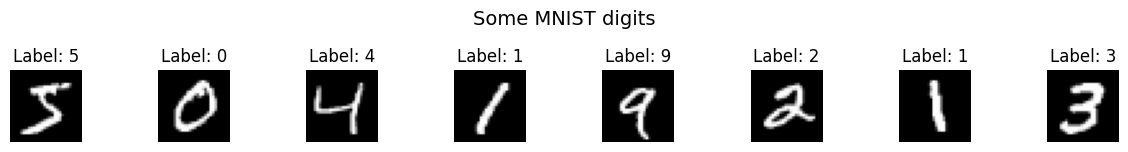

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = load_mnist()

print(f"Training Images : X={X_train.shape}, Training Labels : y={y_train.shape}")
print(f"Validation Images : X={X_val.shape}, Validation Labels : y={y_val.shape}")
print(f"Test Images : X={X_test.shape}, Test Labels : y={y_test.shape}")

# Show a few samples
fig, axes = plt.subplots(1, 8, figsize=(12, 1.5))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].view(28, 28), cmap='gray')
    ax.set_title(str("Label: " + str(y_train[i].item())), fontsize=12)
    ax.axis('off')
plt.suptitle('Some MNIST digits', fontsize=14)
plt.tight_layout()
plt.show()

---

## Activation Functions

---

### ReLU (Rectified Linear Unit)

ReLU is one of the most common activation functions. It keeps positive values and sets negative values to zero:

$$\text{ReLU}(x) = \max(0, x)$$

Its gradient is straightforward:

$$\frac{\partial}{\partial x}\text{ReLU}(x) = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$$

---

### Tanh

Tanh is also an activation function and squashes values to the range `(-1, 1)`:

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Its gradient has a nice form in terms of its **own forward output**:

$$\frac{\partial}{\partial x}\tanh(x) = 1 - \tanh(x)^2$$

---


## **Task**: 

Implement `relu_forward` and `relu_backward` in `mlp_layers.py`.

**Hints**:
- `relu_forward`: Look at `torch.clamp` or `torch.max`.
- `relu_backward`: The gradient is 1 where the input was positive and 0 otherwise. A boolean comparison in PyTorch gives you a mask like that.

In [5]:
tests.test_relu(relu_forward)

✅ PASS: relu is correct.


True

In [6]:
tests.test_relu_backward(relu_forward, relu_backward)

✅ PASS: relu_backward is correct (matches numerical gradient).


True

---

## **Task**: 

Implement `tanh_forward` and `tanh_backward` in `mlp_layers.py`.

**Hints**:
- `tanh_forward`: Use `torch.exp`.
- `tanh_backward`: Remember that you receive the **tanh output**, not the raw input.

In [20]:
tests.test_tanh_forward(tanh_forward)

✅ PASS: tanh_forward is correct.


True

In [21]:
tests.test_tanh_backward(tanh_forward, tanh_backward)

✅ PASS: tanh_backward is correct (matches numerical gradient).


True

---

## Linear Layer

---

A **linear (fully connected) layer** is the basic building block of an MLP. It maps an input vector to an output vector using a weight matrix and a bias:

$$z = xW + b$$

where:
- $x$ is the input vector of shape `(batch_size, in_features=784)` (multiple images in parallel as input)
- $W$ is the weight matrix of shape `(in_features, out_features)`. Each **column** corresponds to one output neuron
- $b$ is the bias vector of shape `(out_features,)`
- $z$ is the output of shape `(batch_size, out_features)`

### Backpropagation

To train the network, we need the gradients of the loss $L$ with respect to the input and the parameters. For this we need the upstream gradient $\frac{\partial L}{\partial z}$ and the local gradients ($\frac{\partial z}{\partial x}$,$\frac{\partial z}{\partial W}$,$\frac{\partial z}{\partial b}$).

### Forward Pass Caching
> **Why a cache?** The forward pass returns a **cache** `(x, W, b)` with the values needed later in the backward pass. These are needed for backpropagation.

---

## **Task**: 

Implement `linear_forward` and `linear_backward` in `mlp_layers.py`.

**Hints**:
  - `torch.transpose` or `Tensor.T` might be helpful.
  - the bias gradient `db` needs to collect the gradient for all images of the batch.

In [8]:
tests.test_linear_forward(linear_forward)

✅ PASS: linear_forward is correct.


True

In [10]:
tests.test_linear_backward(linear_forward, linear_backward)

✅ PASS: linear_backward is correct (matches PyTorch autograd).


True

---

## Loss Function

---

Loss functions measure how wrong the model's predictions are. During training, we try to **minimize** this value by updating the parameters. Lower loss usually means better predictions.

### Softmax

Usually a neural network outputs raw scores $s \in (-\infty ,\infty)$ called **logits**, one per class. To interpret them as probabilities, we pass them through softmax:

$$p_j = \frac{e^{s_j}}{\sum_k e^{s_k}}$$

After softmax, each value is between 0 and 1, and each row sums to 1.

> **Note**: This is the naive implementation. For very large or very small logits, `exp` can overflow or underflow in float32. A numerically stable version will come later.

---

### Cross-Entropy Loss

Cross-entropy measures how well the predicted probabilities match the true class labels:

$$L = -\frac{1}{N}\sum_{i=1}^{N} \log p_{i, y_i}$$

Here, $p_{i, y_i}$ is the predicted probability assigned to the **correct** class of image $i$. The loss is small when the correct class gets high probability.

---

### Gradient

The gradient of the combined softmax + cross-entropy loss **with respect to the pre-softmax logits** has a surprisingly simple form:

$$\frac{\partial L}{\partial s} = \frac{1}{N}(p - \mathbb{1}_y)$$

where $\mathbb{1}_y$ is the one-hot encoding of the targets. **In practice**, start from the probabilities, subtract 1 at the correct class position, and divide by $N$ (batch size).
Note that $p \in \mathbb{R}^{ N \times 10}$ is the complete matrix.

**Are you able to derive it yourself? Try it by considering only one image ($N=1$) at a time!**

---

## **Task**: 

Implement `softmax` in `mlp_layers.py`.

**Hint**: 
- Use `torch.exp`,`torch.sum`. Consider using `keepdim=True` so broadcasting works as expected.

In [14]:
tests.test_softmax(softmax)

✅ PASS: softmax is correct.


True

---

## **Task**: 

Implement `cross_entropy_loss` in `mlp_layers.py`.

**Hints**:
- To pick the probability of the correct class for each sample, use advanced indexing: `tensor[torch.arange(N), ...]`.
- The loss is the **mean** negative log-probability of the correct classes.
- For the gradient `dlogits`: `.clone()` the `probs` tensor, then calculate the gradient.

In [17]:
tests.test_cross_entropy_loss(softmax, cross_entropy_loss)

✅ PASS: cross_entropy_loss is correct (matches F.cross_entropy).


True

---

## MLP Model

---

Our network will have **3 hidden layers** with activations, followed by one **output layer** that produces raw logits. 

The activation function is passed in as an argument so the same code can work with both ReLU and tanh.

### Architecture
```
Input (784) -> Linear -> Act -> Linear -> Act -> Linear -> Act -> Linear -> Logits 
              [784->256]       [256->128]       [128->64]        [64->10]   (10)  
```



### Initialization

Weights are initialized with small random values:

$$W \sim \mathcal{N}(0, 0.1), \quad b = 0$$

> **Why random?** If all weights started with the same value, every neuron in a layer would learn the same features. Small random initialization breaks that.

### Forward and Backward

- **Forward pass**: send the input through each layer in order and store intermediate values in a cache.
- **Backward pass**: walk through the network in reverse and apply the chain rule to compute gradients.

---

## **Task**: 

Implement `init_model`, `forward_pass`, and `backward_pass` in `model.py`.

**Hints**:
- `init_model`: Use `torch.randn` for weights and `torch.zeros` for biases. 
- `forward_pass`: The last layer has **no activation** because it should output raw logits.
- `backward_pass`: Store the needed  intermediates in a dictionary.
- `backward_pass`: Start from `dlogits` and move backward layer by layer.

In [20]:
tests.test_init_model(init_model)

✅ PASS: init_model is correct.


True

In [24]:
tests.test_forward_pass(forward_pass, init_model)

✅ PASS: forward_pass is correct.


True

In [27]:
tests.test_backward_pass(forward_pass, backward_pass, softmax, cross_entropy_loss, init_model)

✅ PASS: backward_pass is correct (matches PyTorch autograd).


True

---

## Training Utilities

---

Before writing the full training loop, we implement three small helper functions:

### Batching:

Instead of computing gradients on all 50,000 training images at once, we shuffle the data and split it into small **batches** such as 64 images. Each batch gives a noisy but efficient gradient estimate.

### SGD (Stochastic Gradient Descent):

The simplest optimization rule is to move each parameter a small step in the direction that reduces the loss:

$$\theta \leftarrow \theta - \eta \nabla_\theta L$$

where $\eta$ is the **learning rate**, a small number such as `0.01` that controls the step size.

### Accuracy:

To evaluate the model, we compute the ratio $r \in [0,1]$ of predictions that match the true labels. The predicted class is the index of the largest logit.

---

## **Task**: 

Implement `compute_accuracy`, `create_batches`, and `sgd_step` in `train.py`.

**Hints**:
- `create_batches`: Use `torch.randperm` to generate a random permutation. Apply the **same** permutation to both `X` and `y` so they stay aligned.
- `sgd_step`: For each parameter key in `params`, select its gradient with grads['d' + key]`.
- `compute_accuracy`: Use `torch.argmax` to get the predicted class, and then compare it with the true labels.

In [34]:
tests.test_compute_accuracy(compute_accuracy, forward_pass, init_model)

✅ PASS: compute_accuracy is correct.


True

In [38]:
tests.test_create_batches(create_batches)

KeyboardInterrupt: 

In [42]:
tests.test_sgd_step(sgd_step)

✅ PASS: sgd_step is correct.


True

---

## Training Loop

---

Now put everything together. 

In each epoch:

1. **Create batches** from the training data
2. **Loop over every batch. Execute**: forward pass -> loss -> backward pass -> SGD
3. **Record metrics**: train/val loss and accuracy

> **Hint**: An 'epoch'  means training on every image of the training set once. 

---

## **Task**: 


Implement `train` in `train.py`.

In [ ]:
tests.test_train(train, forward_pass, backward_pass, softmax, cross_entropy_loss, init_model, load_mnist)

---

## Training with ReLU

---

Train the full model with ReLU activations using 20 epochs, batch size 64, and learning rate 0.01.

As training progresses, the loss should decrease and the accuracy should increase.
At the end, you should see a val accuracy of 96-97\%.

In [ ]:
params_relu = init_model()

history_relu = train(
    X_train, y_train, X_val, y_val, params_relu,
    forward_pass, backward_pass, softmax, cross_entropy_loss,
    relu_forward, relu_backward,
    epochs=20, batch_size=64, learning_rate=0.01
)

---

Plot Training

---

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_relu['train_loss'], label='Train')
ax1.plot(history_relu['val_loss'], label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('ReLU - Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history_relu['train_acc'], label='Train')
ax2.plot(history_relu['val_acc'], label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('ReLU - Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
test_acc_relu = compute_accuracy(X_test, y_test, params_relu, forward_pass, relu_forward)
print(f"ReLU test accuracy: {test_acc_relu:.2%}")

---

## Training with Tanh

---

Re-initialize the model with fresh random weights and train again using tanh with the same hyperparameters. This gives a fair comparison between the two activations.

At the end, you should see a val accuracy of 96-97\%.

In [ ]:
params_tanh = init_model()

history_tanh = train(
    X_train, y_train, X_val, y_val, params_tanh,
    forward_pass, backward_pass, softmax, cross_entropy_loss,
    tanh_forward, tanh_backward,
    epochs=20, batch_size=64, learning_rate=0.01
)

---

Plot Training

---

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_tanh['train_loss'], label='Train')
ax1.plot(history_tanh['val_loss'], label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Tanh - Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history_tanh['train_acc'], label='Train')
ax2.plot(history_tanh['val_acc'], label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Tanh - Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
test_acc_tanh = compute_accuracy(X_test, y_test, params_tanh, forward_pass, tanh_forward)
print(f"Tanh test accuracy: {test_acc_tanh:.2%}")

---

## Comparison

---

Compare the two activation functions side by side. Focus on:
- **Convergence speed**: Which activation improves faster in the first few epochs?
- **Final accuracy**: Do they end up at similar performance, or does one do better?

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_relu['val_loss'], label='ReLU')
ax1.plot(history_tanh['val_loss'], label='Tanh')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation Loss')
ax1.set_title('Validation Loss - ReLU vs Tanh'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history_relu['val_acc'], label='ReLU')
ax2.plot(history_tanh['val_acc'], label='Tanh')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy - ReLU vs Tanh'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"ReLU test accuracy: {test_acc_relu:.2%}")
print(f"Tanh test accuracy: {test_acc_tanh:.2%}")